In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("ai_workforce_displacement_global_2020_2026.csv")
df['quarter_label'] = pd.Categorical(df['quarter_label'], ordered=True)

In [3]:
df=df.drop('data_source_notes',axis=1)

In [4]:
cols=df.columns

In [5]:
industries=df[cols[8]].unique()
quarter_lab=cols[7]

In [12]:
ai_risk=[]
for x,industry in enumerate(industries):
    industry_data=df[df[cols[8]]==industry].groupby(quarter_lab).agg(ai_risk=('sector_automation_risk_score','mean')).reset_index()
    ai_risk.append([industry,industry_data])

In [9]:
# Repeating this for facet grid to produce timeseries overtime

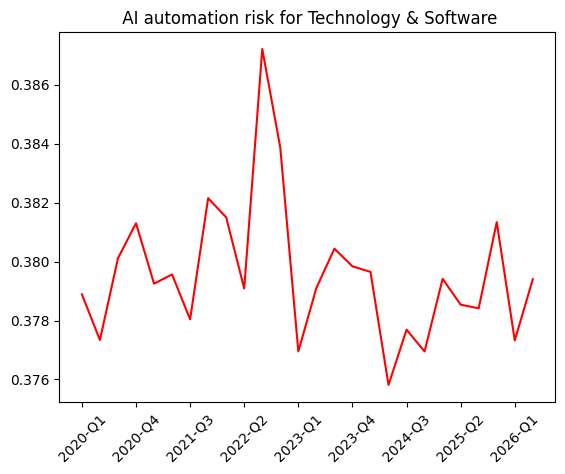

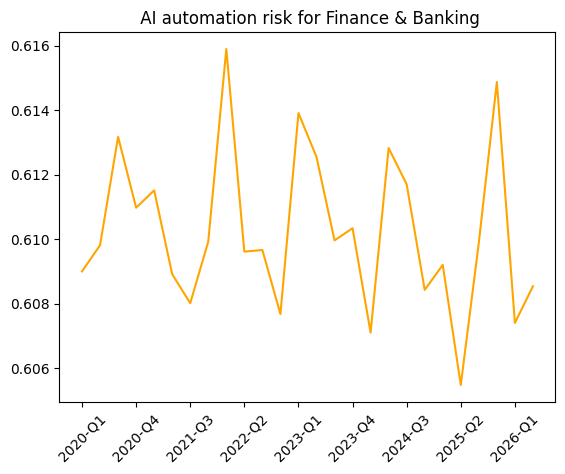

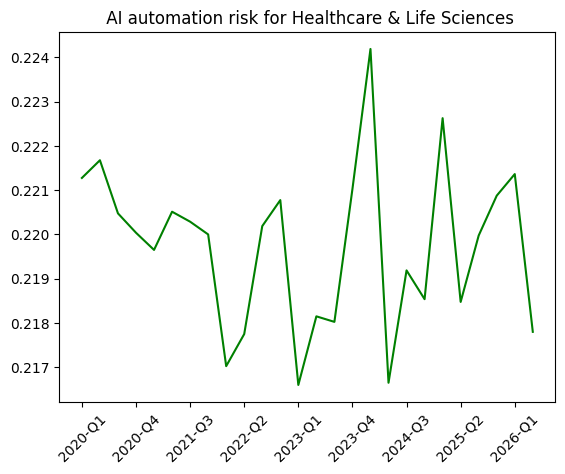

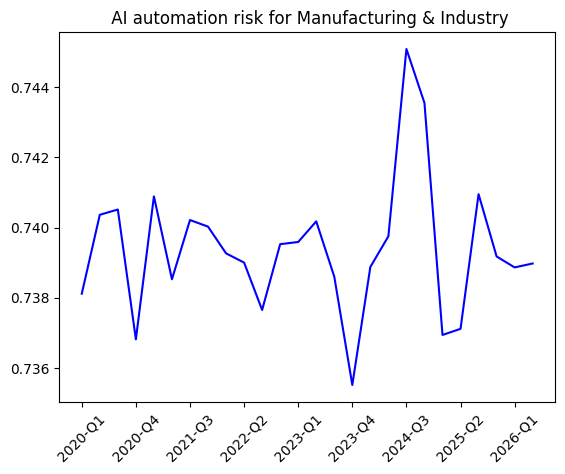

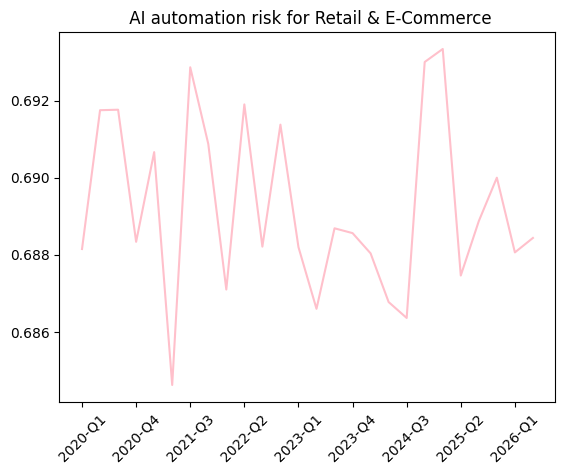

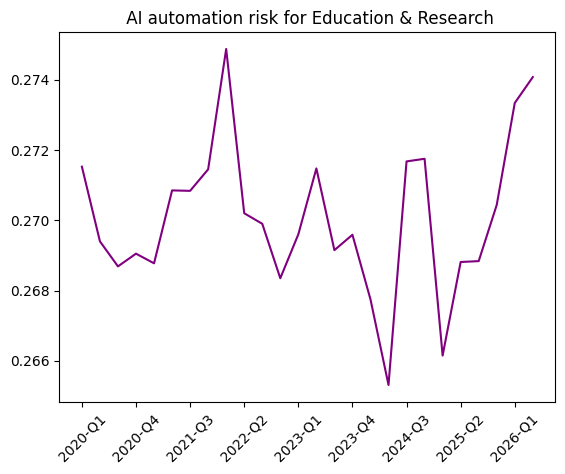

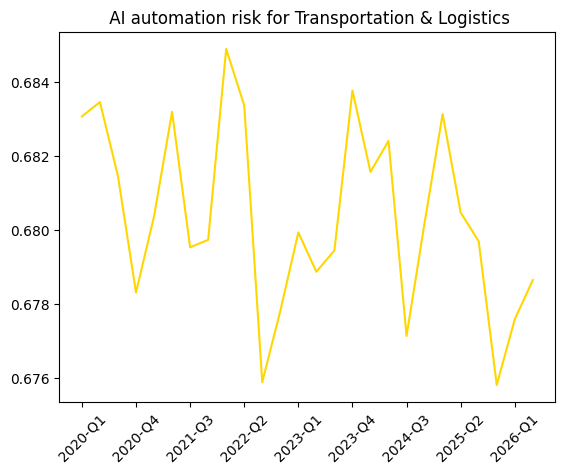

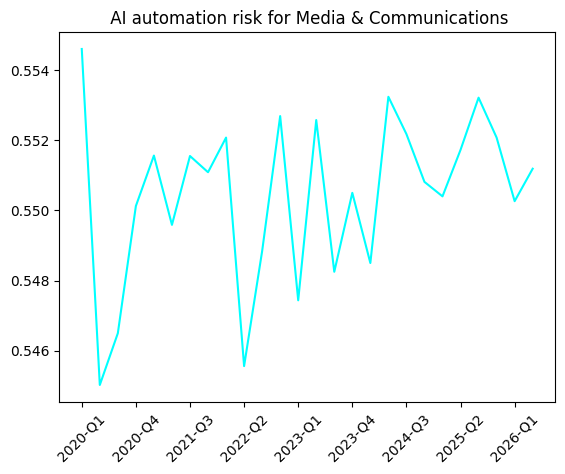

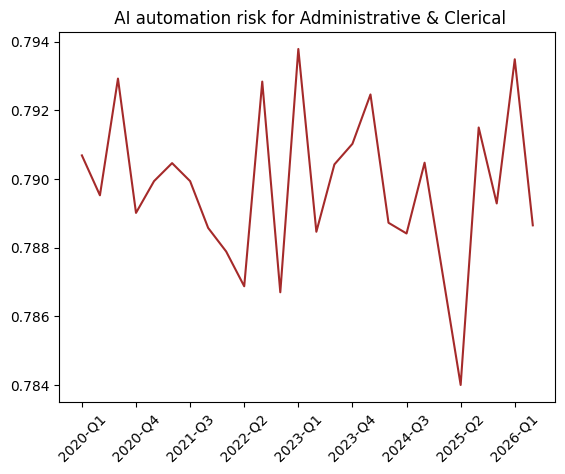

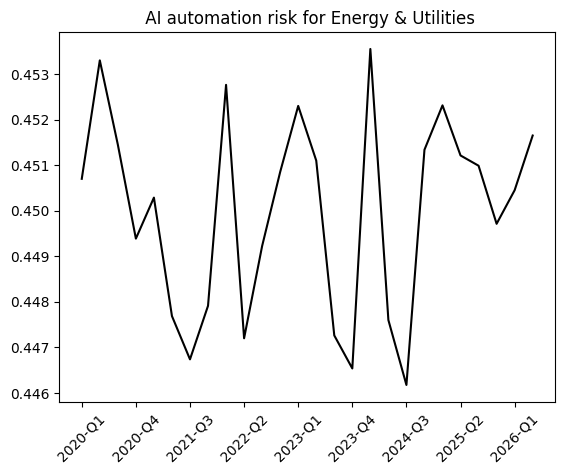

In [13]:
colors=['red','orange','green','blue','pink','purple','gold','cyan','brown','black']
for i,data in enumerate(ai_risk):
    plt.figure()
    plt.plot(data[1]['quarter_label'],data[1]['ai_risk'],color=colors[i])
    plt.title(f" AI automation risk for {data[0]}")
    quarters=data[1]['quarter_label'][::3]
    plt.xticks(quarters,rotation=45)
    plt.savefig(f"AI automation overtime {data[0]}.png")

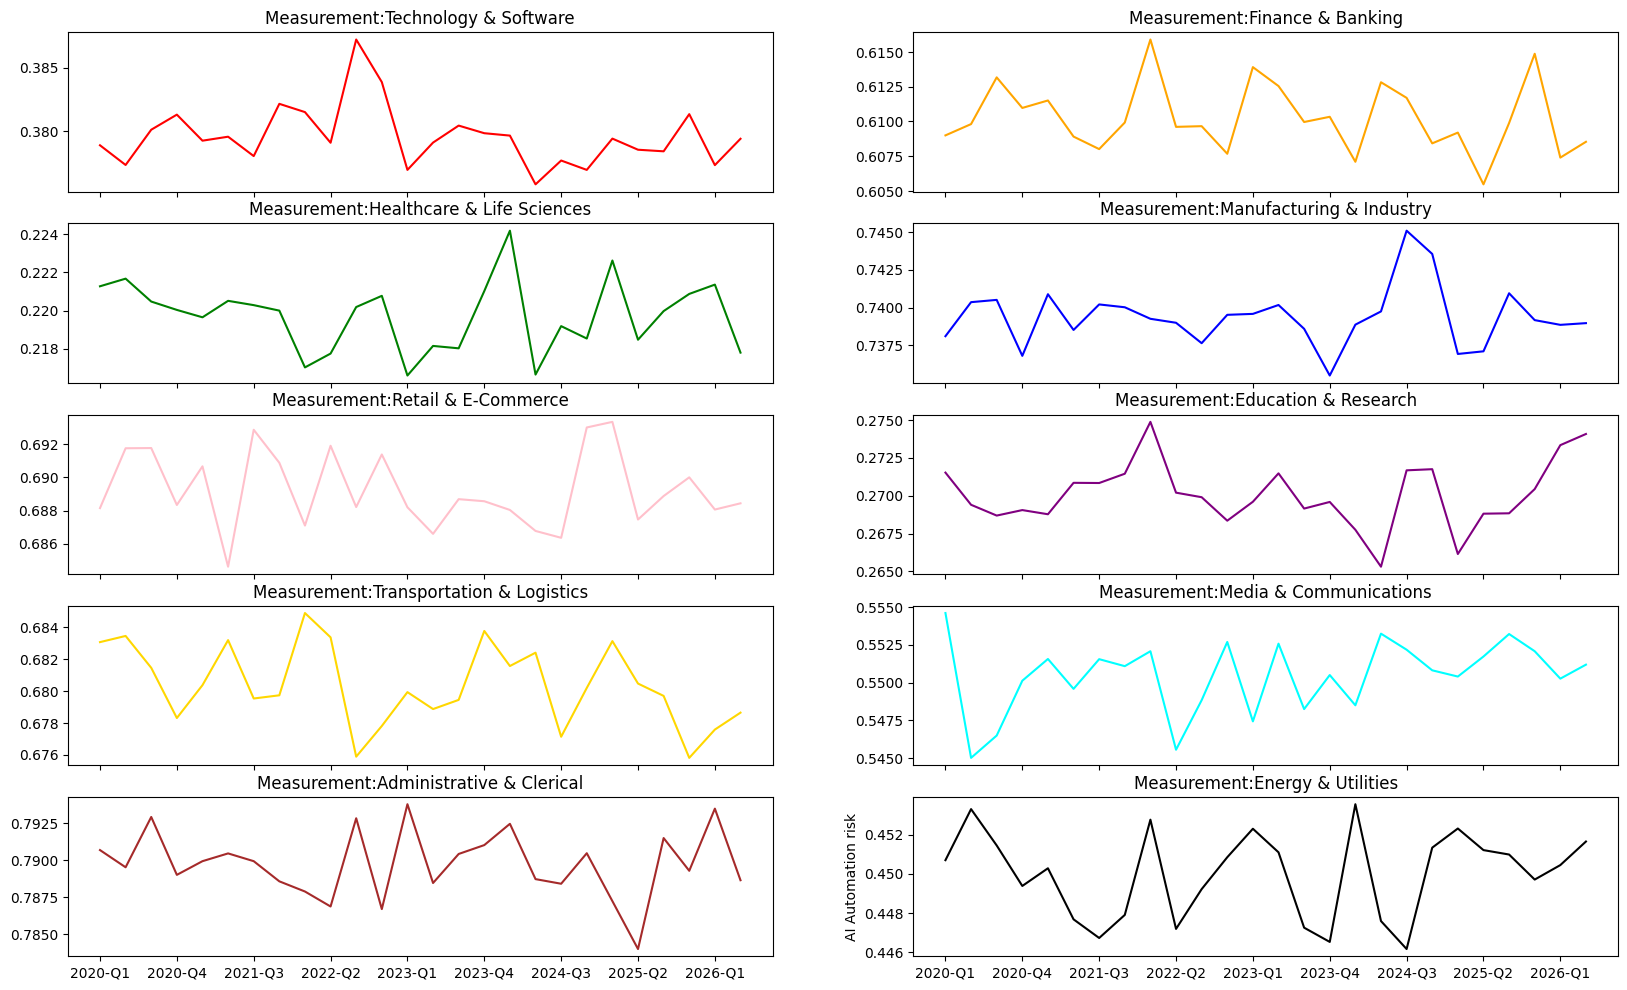

In [14]:
fig,axs=plt.subplots(5,2,figsize=(20,12),sharex=True)
for i in range(len(ai_risk)):
    x=ai_risk[i][1]['quarter_label']
    y=ai_risk[i][1]['ai_risk']
    axs.flatten()[i].plot(x,y,color=colors[i])
    axs.flatten()[i].set_title(f'Measurement:{ai_risk[i][0]}')

plt.xticks(quarters)
plt.ylabel("AI Automation risk")
plt.savefig("facetgridtime.png")

In [35]:
for i in range(len(ai_risk)):
    print(ai_risk[i][0],ai_risk[i][1]['ai_risk'].mean())

Technology & Software 0.37958269230769237
Finance & Banking 0.6102447115384616
Healthcare & Life Sciences 0.2197355769230769
Manufacturing & Industry 0.7393860576923077
Retail & E-Commerce 0.68923125
Education & Research 0.2700711538461539
Transportation & Logistics 0.6803793269230769
Media & Communications 0.5504442307692308
Administrative & Clerical 0.7897423076923077
Energy & Utilities 0.4499879807692308


In [ ]:
df['industry_sector']

In [37]:
df.groupby('industry_sector')['sector_automation_risk_score'].mean().sort_values()

industry_sector
Healthcare & Life Sciences    0.219736
Education & Research          0.270071
Technology & Software         0.379583
Energy & Utilities            0.449988
Media & Communications        0.550444
Finance & Banking             0.610245
Transportation & Logistics    0.680379
Retail & E-Commerce           0.689231
Manufacturing & Industry      0.739386
Administrative & Clerical     0.789742
Name: sector_automation_risk_score, dtype: float64

In [38]:
df

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_displaced,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,...,0.0406,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,...,0.0517,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.198,...,0.0176,0.0168,-0.0008,4,0.278,0.72,0.707,37,6.8,0.202
3,4,United States,USA,North America,High Income,2020,1,2020-Q1,Manufacturing & Industry,0.720,...,0.0924,0.0642,-0.0282,47,0.268,0.29,0.310,50,6.8,0.655
4,5,United States,USA,North America,High Income,2020,1,2020-Q1,Retail & E-Commerce,0.676,...,0.0667,0.0374,-0.0293,31,0.313,0.54,0.547,37,6.2,0.542
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20795,20796,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Education & Research,0.308,...,0.0218,0.0056,-0.0162,29,0.450,0.58,0.651,16,3.5,0.184
20796,20797,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Transportation & Logistics,0.675,...,0.0534,0.0205,-0.0329,126,0.476,0.22,0.235,15,4.2,0.457
20797,20798,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Media & Communications,0.516,...,0.0505,0.0154,-0.0351,131,0.446,0.46,0.482,17,4.3,0.419
20798,20799,Zambia,ZMB,Africa,Lower Middle Income,2026,2,2026-Q2,Administrative & Clerical,0.801,...,0.0914,0.0260,-0.0654,476,0.499,0.79,0.950,14,4.2,0.459


In [48]:
np.round(df.groupby('industry_sector')['net_workforce_change_pct'].mean().sort_values(ascending=False)*100,3)

industry_sector
Healthcare & Life Sciences   -0.748
Education & Research         -0.932
Energy & Utilities           -1.518
Technology & Software        -1.667
Media & Communications       -1.989
Finance & Banking            -2.204
Transportation & Logistics   -2.517
Retail & E-Commerce          -2.668
Manufacturing & Industry     -2.912
Administrative & Clerical    -3.370
Name: net_workforce_change_pct, dtype: float64

In [15]:
max_diffs=dict()
for x,industry in enumerate(industries):
    industry_data=df[df[cols[8]]==industry].groupby(quarter_lab).agg(ai_risk=('sector_automation_risk_score','mean')).reset_index()
    max_diffs[industry]=industry_data['ai_risk'].max()-industry_data['ai_risk'].min()

In [16]:
max_diffs

{'Technology & Software': np.float64(0.011400000000000021),
 'Finance & Banking': np.float64(0.010425000000000018),
 'Healthcare & Life Sciences': np.float64(0.007587499999999997),
 'Manufacturing & Industry': np.float64(0.009575),
 'Retail & E-Commerce': np.float64(0.008712499999999901),
 'Education & Research': np.float64(0.00956250000000003),
 'Transportation & Logistics': np.float64(0.009087500000000137),
 'Media & Communications': np.float64(0.00957499999999989),
 'Administrative & Clerical': np.float64(0.009787499999999949),
 'Energy & Utilities': np.float64(0.007374999999999965)}

In [83]:
df['quarter_label'].unique()

['2020-Q1', '2020-Q2', '2020-Q3', '2020-Q4', '2021-Q1', ..., '2025-Q2', '2025-Q3', '2025-Q4', '2026-Q1', '2026-Q2']
Length: 26
Categories (26, str): ['2020-Q1' < '2020-Q2' < '2020-Q3' < '2020-Q4' ... '2025-Q3' < '2025-Q4' < '2026-Q1' < '2026-Q2']

In [11]:
# Getting Jobs displaced by AI each quarter for different industries

In [31]:
displaced_jobs=[]

for industry in industries:
    industry
    displaced_data=df[df['industry_sector']==industry]
    displaced_group=displaced_data.groupby(quarter_lab).agg(total_displaced=('pct_sector_workforce_displaced','mean')).reset_index()
    displaced_jobs.append([industry,displaced_group])
    

In [36]:
net_jobs=df.groupby(quarter_lab).agg(net_jobs=('net_workforce_change_pct','mean')).reset_index()

In [59]:
net_jobs=[]
for x,industry in enumerate(industries):
    industry_data=df[df['industry_sector']==industry].groupby(quarter_lab).agg(net_jobs=('net_workforce_change_pct','mean')).reset_index()
    net_jobs.append([industry,industry_data])

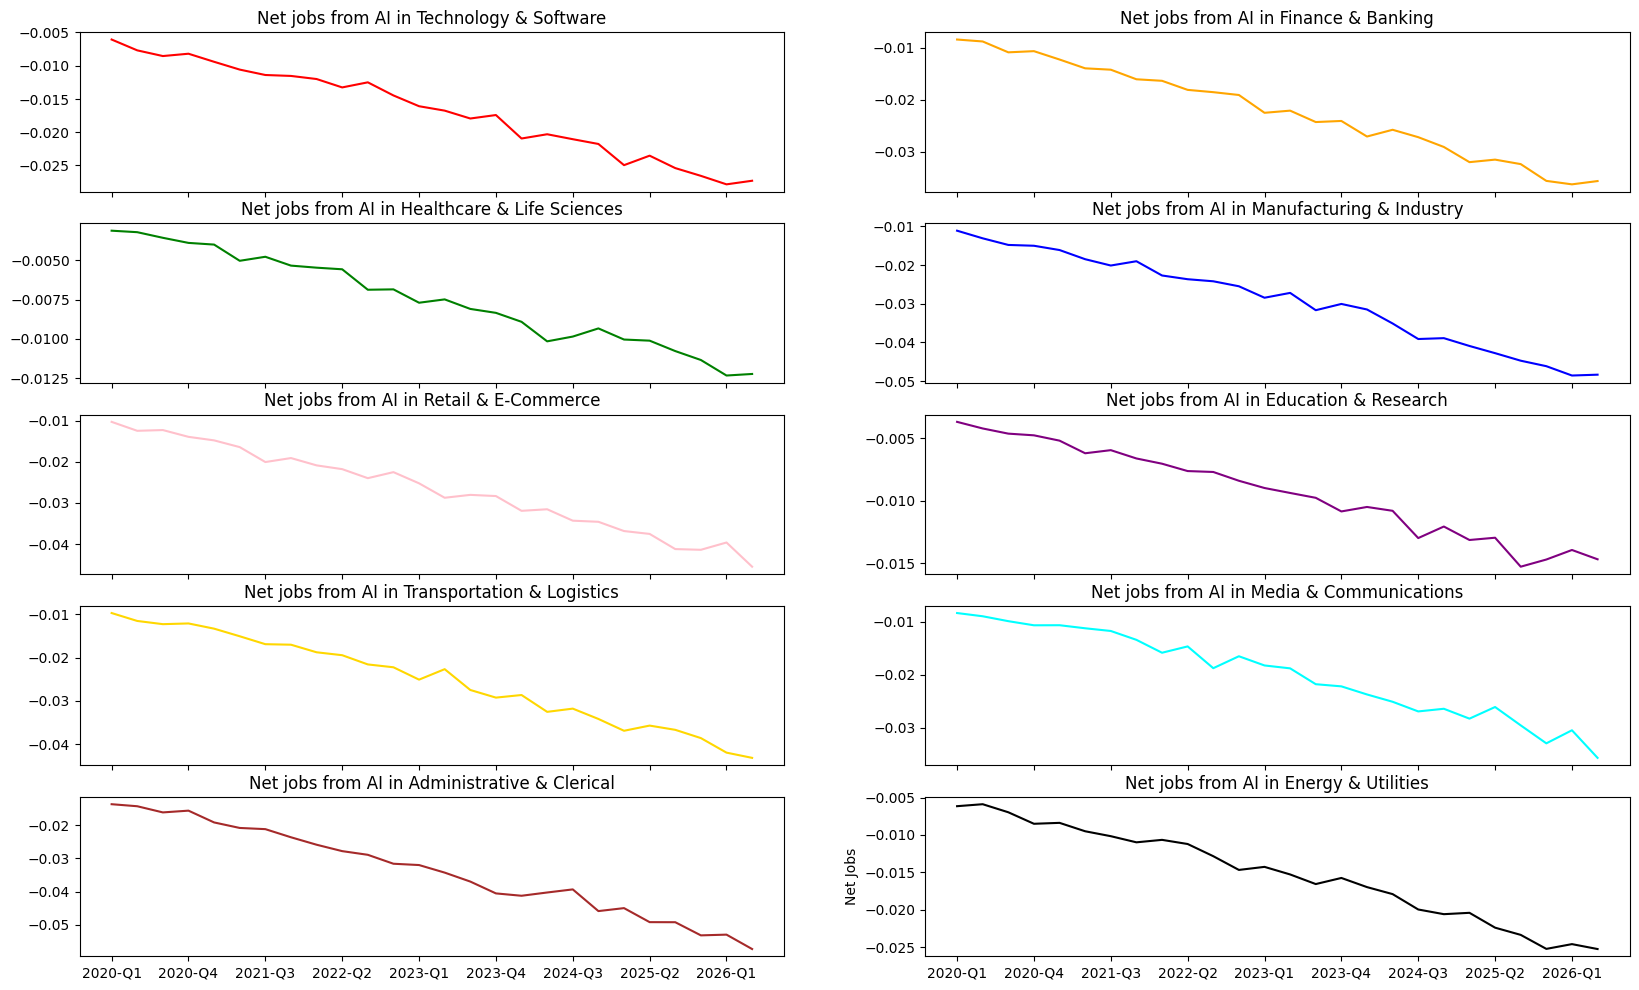

In [69]:
fig,axs=plt.subplots(5,2,figsize=(20,12),sharex=True)
for i in range(len(net_jobs)):
    x=net_jobs[i][1]['quarter_label']
    y=net_jobs[i][1]['net_jobs']
    axs.flatten()[i].plot(x,y,color=colors[i])
    axs.flatten()[i].set_title(f'Net jobs from AI in {net_jobs[i][0]}')

plt.xticks(quarters)
plt.ylabel("Net Jobs")
plt.savefig("facetgridjobs.png")

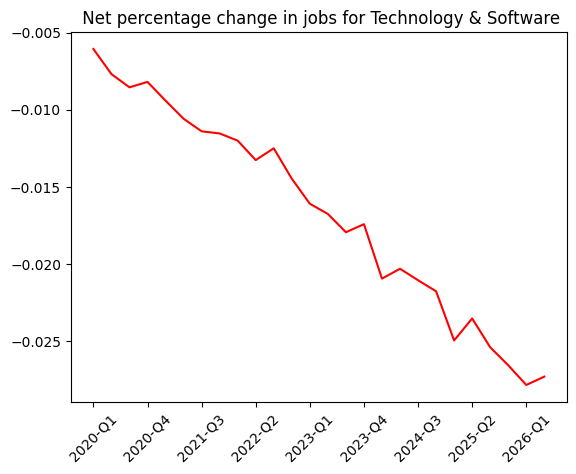

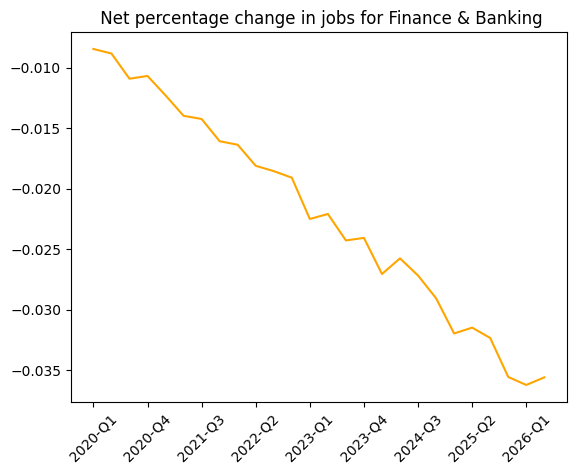

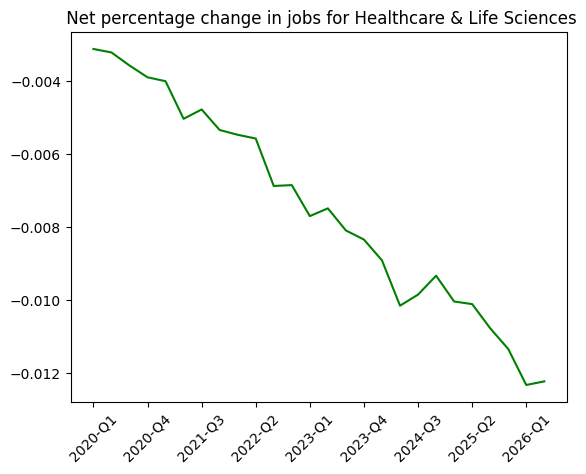

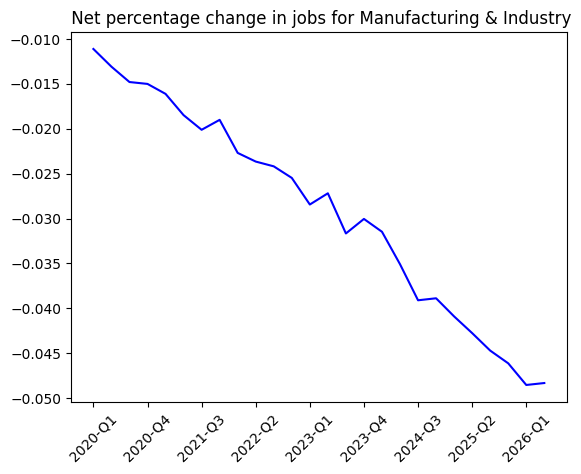

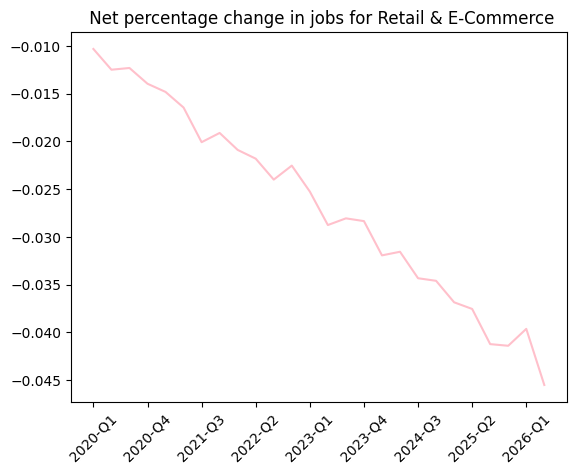

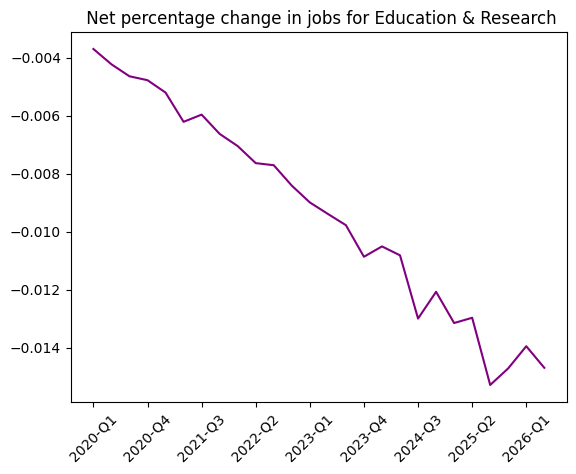

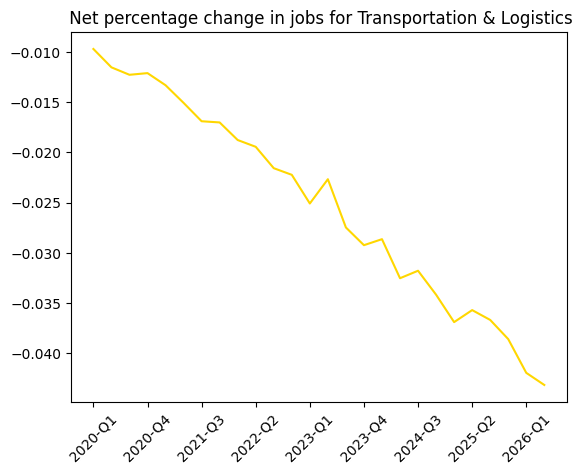

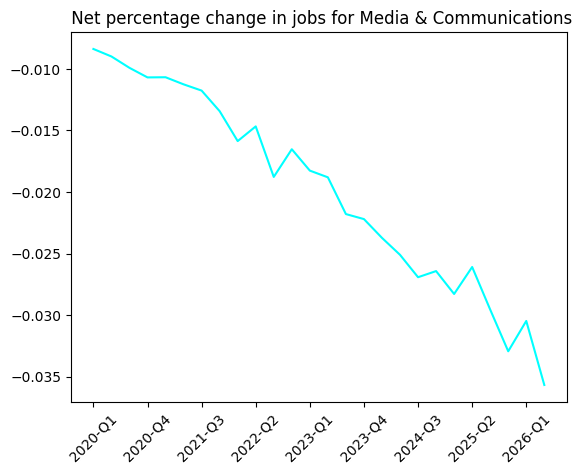

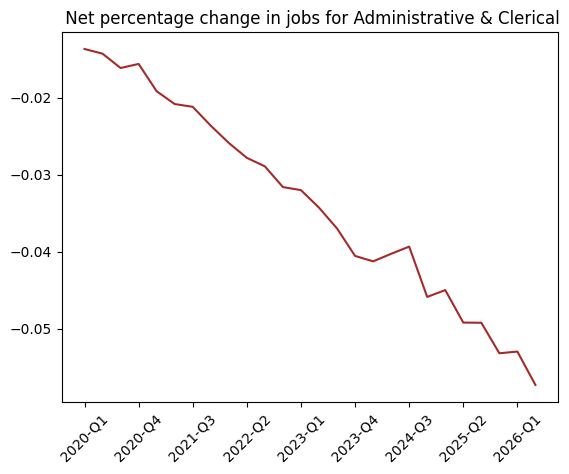

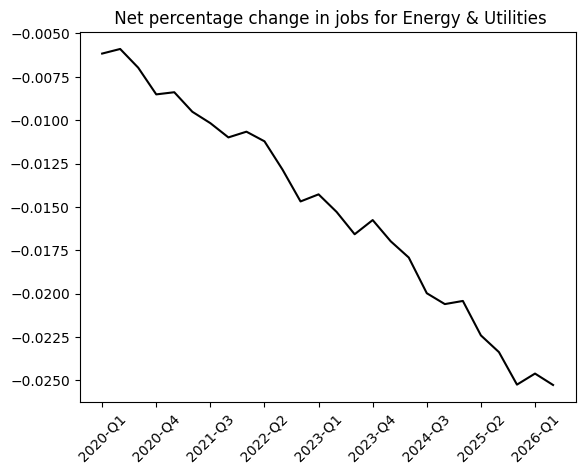

In [70]:
colors=['red','orange','green','blue','pink','purple','gold','cyan','brown','black']
for i,data in enumerate(net_jobs):
    plt.figure()
    plt.plot(data[1]['quarter_label'],data[1]['net_jobs'],color=colors[i])
    plt.title(f" Net percentage change in jobs for {data[0]}")
    quarters=data[1]['quarter_label'][::3]
    plt.xticks(quarters,rotation=45)
    plt.savefig(f"AI net jobs overtime {data[0]}.png")

In [77]:
jobs_df=df.groupby('quarter_label').agg(jobs_lost_per=('net_workforce_change_pct','mean')).reset_index()

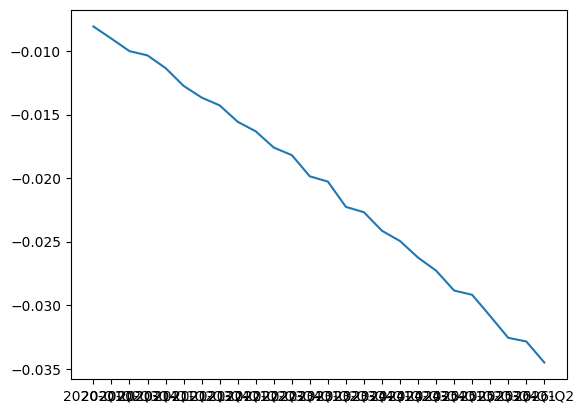

In [78]:
plt.plot(jobs_df['quarter_label'],jobs_df['jobs_lost_per'])

In [80]:
jobs_ai_df=df.groupby('quarter_label').agg(jobs_lost=('net_workforce_change_pct','mean'),ai_risk=('sector_automation_risk_score','mean')).reset_index()

In [81]:
jobs_ai_df

,quarter_label,jobs_lost,ai_risk
0,2020-Q1,-0.008066,0.538601
1,2020-Q2,-0.009022,0.538165
2,2020-Q3,-0.010006,0.538706
3,2020-Q4,-0.010343,0.537335
4,2021-Q1,-0.011336,0.538290
5,2021-Q2,-0.012739,0.537392
6,2021-Q3,-0.013658,0.537801
7,2021-Q4,-0.014277,0.538174
8,2022-Q1,-0.015563,0.539329
9,2022-Q2,-0.016317,0.537056
